In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df = pd.read_csv('/Users/divyanshailani/Desktop/systems-engineering-labs/Ai:Ml/Pandas/IPL/data/processed/cleaned_ipl.csv' , low_memory = False)

##### wicket kinds bar

In [59]:
wicket_types =df['wicket_kind'].value_counts()


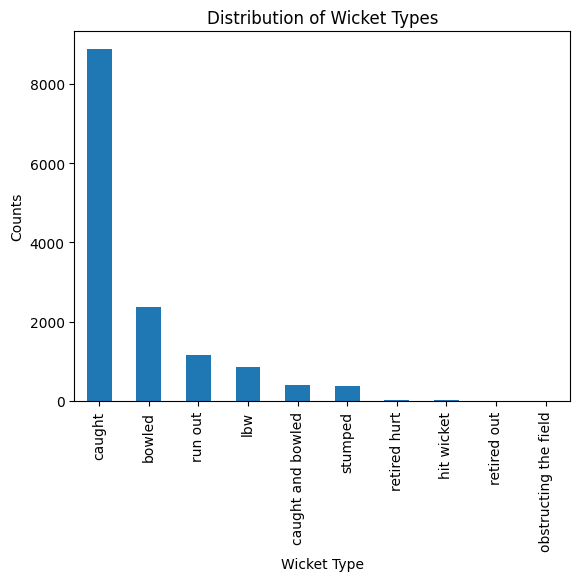

In [99]:
wicket_types.plot(kind = 'bar')
plt.title('Distribution of Wicket Types')
plt.xlabel('Wicket Type')
plt.ylabel('Counts')
plt.xticks(rotation = 90 )   
plt.show()

##### Team wining percentages

In [61]:
same_matches = df.drop_duplicates(subset = 'match_id')


In [72]:
team_mapping ={'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
               'Delhi Daredevils': 'Delhi Capitals',
               'Punjab Kings' : 'Kings XI Punjab',
               'Rising Pune Supergiants': 'Rising Pune Supergiant'}

In [74]:
match_win_team = same_matches['match_won_by'].replace(team_mapping).value_counts()
match_win_team


match_won_by
Mumbai Indians                 152
Chennai Super Kings            144
Royal Challengers Bangalore    136
Kolkata Knight Riders          135
Kings XI Punjab                123
Delhi Capitals                 120
Rajasthan Royals               118
Sunrisers Hyderabad             95
Gujarat Titans                  39
Lucknow Super Giants            32
Deccan Chargers                 29
Unknown                         24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [75]:
team_cols = ['batting_team', 'bowling_team', 'match_won_by', 'toss_winner']
for col in team_cols:
    df[col] = df[col].replace(team_mapping)

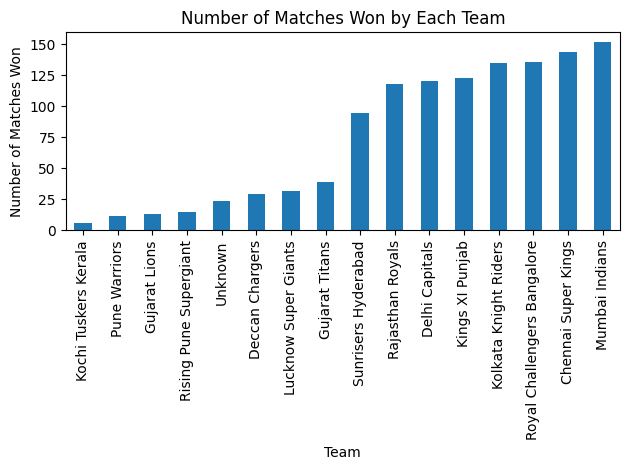

In [97]:
match_win_team .plot(kind = 'bar')
plt.title('Number of Matches Won by Each Team')
plt.xlabel('Team')
plt.ylabel('Number of Matches Won')
plt.xticks(rotation = 90)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

##### Best batsmen per season

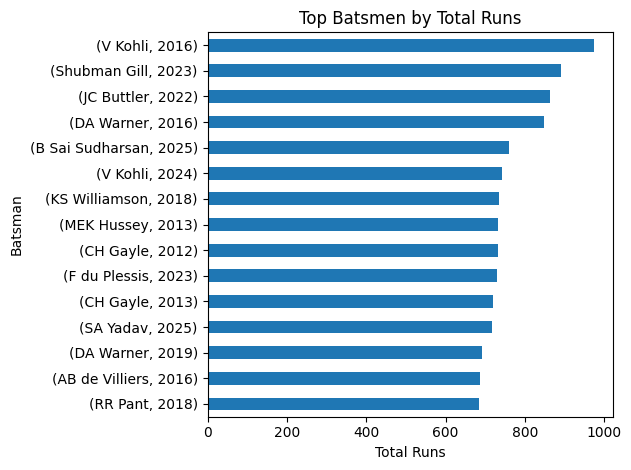

In [119]:
best_batsmen = df.groupby(['batter' , 'season'])['runs_batter'].sum().sort_values(ascending = False).head(15)
best_batsmen.plot(kind = 'barh'  )
#plt.gca().set_facecolor('black')

plt.title('Top Batsmen by Total Runs')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##### season winners

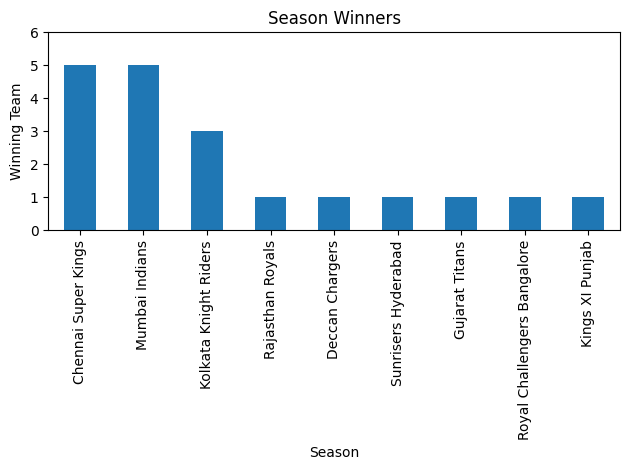

In [176]:
season_winners = df.drop_duplicates(subset = 'match_id').sort_values('date').groupby('season')['match_won_by'].last()
trophy_counts = season_winners.value_counts()
trophy_counts.plot(kind = 'bar')
plt.title('Season Winners')
plt.xlabel('Season')
plt.ylabel('Winning Team')
plt.ylim(0, trophy_counts.max() + 1)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

##### Best chase team

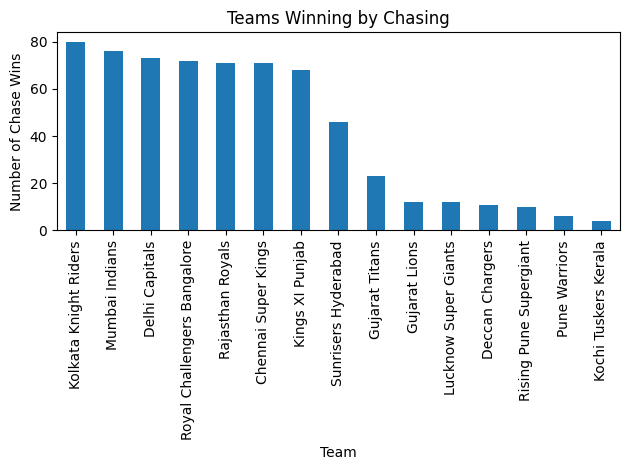

In [177]:
innings2 = df[df['innings'] == 2]
innings2_unique = innings2.drop_duplicates(subset='match_id')
successful = innings2_unique[innings2_unique['batting_team'] == innings2_unique['match_won_by']]
chase_wins = successful['batting_team'].value_counts()

chase_wins.plot(kind = 'bar')
plt.title('Teams Winning by Chasing')
plt.xlabel('Team')
plt.ylabel('Number of Chase Wins')
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [178]:
df.columns


Index(['match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs',
       'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter',
       'striker_out'],
      dtype='str')

In [ ]:
]

0         none
1         none
2         none
3         none
4         none
          ... 
283673    none
283674    none
283675    none
283676    none
283677    none
Name: superover_winner, Length: 283678, dtype: str